
--- MATRICE DE CORRÉLATION (1998 - 2024) ---
           Equity   Rate  Currency  Commodity
Equity      1.000 -0.063    -0.075     -0.013
Rate       -0.063  1.000    -0.125      0.129
Currency   -0.075 -0.125     1.000     -0.019
Commodity  -0.013  0.129    -0.019      1.000
---------------------------------------------

Optimisation In-Sample en cours (Score Sharpe + Rendement)...

--- PONDÉRATIONS OPTIMALES (Score Composite) ---
              Equity     Rate Currency Commodity
slowdown     28.94 %  45.44 %  12.29 %   13.33 %
crisis        10.0 %  31.27 %  45.59 %   13.14 %
goldilocks   15.11 %  44.72 %  30.17 %    10.0 %
reflation    15.34 %   50.0 %   10.0 %   24.66 %
stagflation  18.76 %  41.03 %  10.17 %   30.04 %

--- Métriques NETTES In-Sample (1998 - 2014) ---
                       Passif   Actif
Rendement Annualisé     4.99%   5.61%
Volatilité Annualisée   3.97%   3.69%
Sharpe Ratio             1.26    1.52
Max Drawdown           -6.89%  -4.29%
Calmar Ratio             0.72  

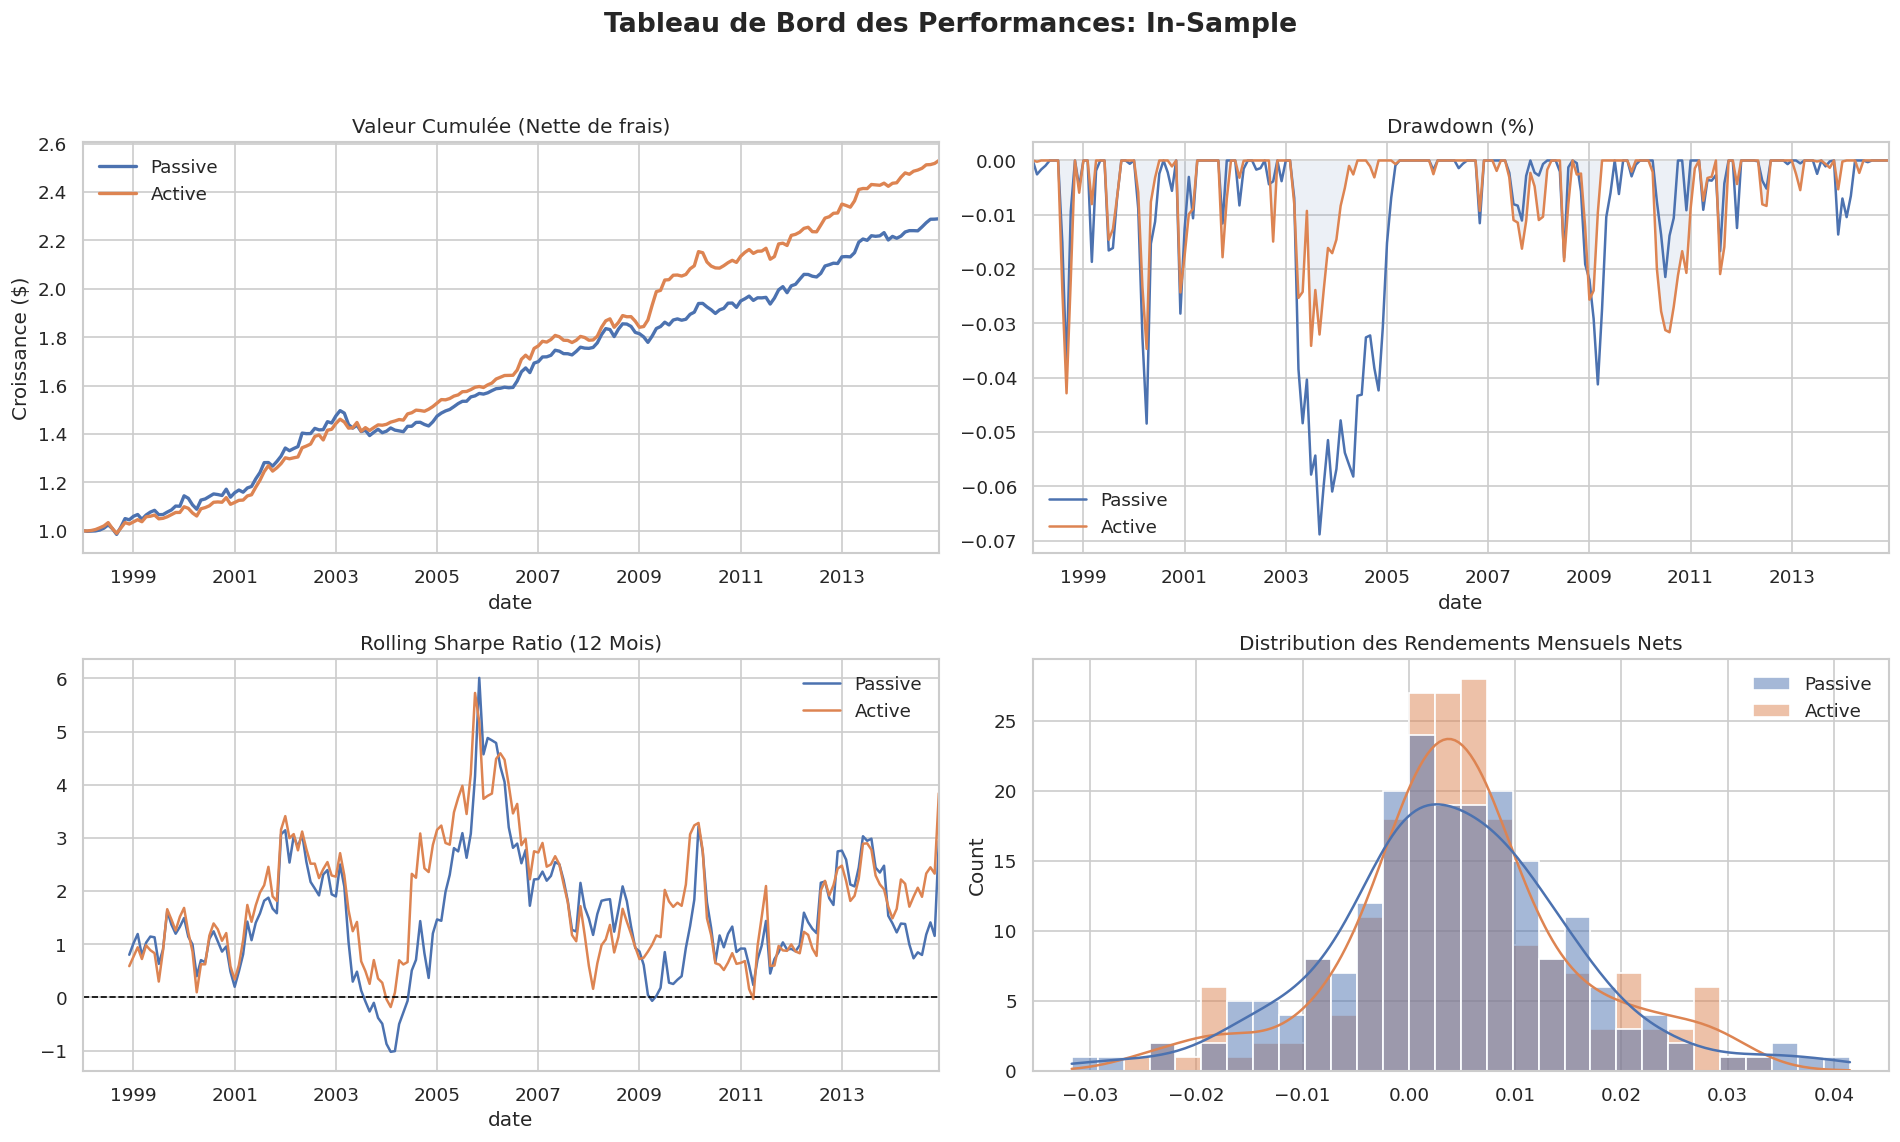

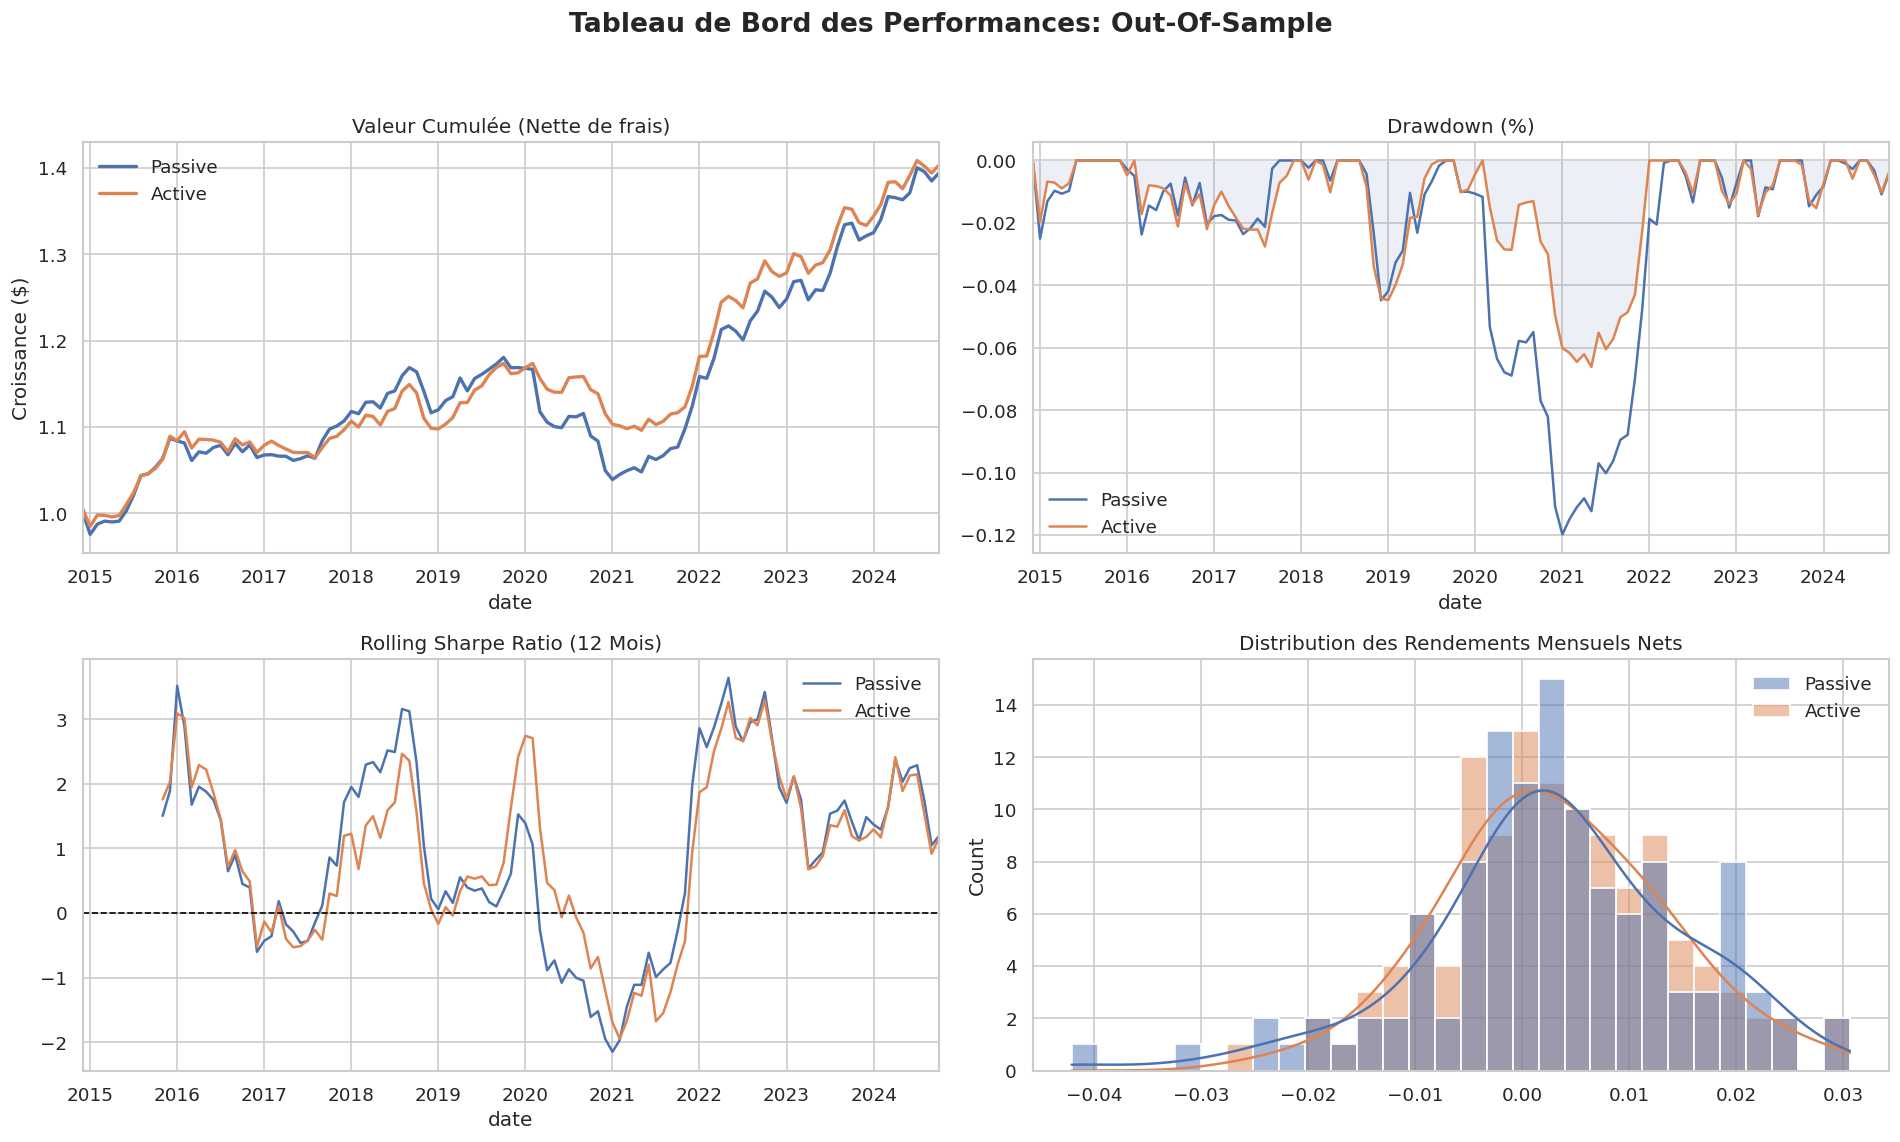

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Chargement et préparation des données
# ---------------------------------------------------------
commo = pd.read_excel('Commo_Strategy_Monthly_Returns.xlsx', sheet_name='3_Facteurs').iloc[:, :2]
commo.columns = ['date', 'Commodity']
commo['date'] = pd.to_datetime(commo['date']).dt.to_period('M').dt.to_timestamp('M')

curr = pd.read_excel('PPP_Pure_Strategy_Returns_EOM_Net.xlsx', sheet_name='PPP_Pure_Net').iloc[:, :2]
curr.columns = ['date', 'Currency']
curr['date'] = pd.to_datetime(curr['date']).dt.to_period('M').dt.to_timestamp('M')

eq_is = pd.read_csv('insample_allocation.csv')
eq_is = eq_is[eq_is['strategy'] == 'C_ValueQualityMom'][['date', 'ls_ret']]
eq_is.columns = ['date', 'Equity']
eq_is['date'] = pd.to_datetime(eq_is['date']).dt.to_period('M').dt.to_timestamp('M')

eq_oos = pd.read_csv('master_allocation.csv')
eq_oos = eq_oos[eq_oos['strategy'] == 'C_ValueQualityMom'][['date', 'ls_ret']]
eq_oos.columns = ['date', 'Equity']
eq_oos['date'] = pd.to_datetime(eq_oos['date']).dt.to_period('M').dt.to_timestamp('M')

equity = pd.concat([eq_is, eq_oos]).drop_duplicates(subset=['date']).sort_values('date')

rates = pd.read_excel('fi_combo_global_quarterly_log_returns.xlsx', sheet_name='Sheet1').iloc[:, :2]
rates.columns = ['date', 'Rate']
rates['date'] = pd.to_datetime(rates['date']).dt.to_period('M').dt.to_timestamp('M')

macro = pd.read_csv('macro_regimes.csv').iloc[:, :2]
macro.columns = ['date', 'regime']
macro['date'] = pd.to_datetime(macro['date']).dt.to_period('M').dt.to_timestamp('M')

# ---------------------------------------------------------
# 2. Fusion et conversions
# ---------------------------------------------------------
df = equity.merge(commo, on='date', how='inner')\
           .merge(curr, on='date', how='inner')\
           .merge(rates, on='date', how='inner')\
           .merge(macro, on='date', how='inner')

df.set_index('date', inplace=True)
df.sort_index(inplace=True)

df['Commodity'] = np.exp(df['Commodity']) - 1
df['Currency']  = np.exp(df['Currency']) - 1
df['Rate']      = np.exp(df['Rate']) - 1

split_date = '2014-12-31'
df_is = df.loc[:split_date].copy()
df_oos = df.loc[split_date:].copy()

assets = ['Equity', 'Rate', 'Currency', 'Commodity']
regimes = df['regime'].unique()
tc_array = np.array([0.0050, 0.0010, 0.0010, 0.0020])

# -> AFFICHAGE DE LA MATRICE DE CORRÉLATION <-
print("\n--- MATRICE DE CORRÉLATION (1998 - 2024) ---")
print(df[assets].corr().round(3))
print("-" * 45)

# ---------------------------------------------------------
# 3. Optimisation ML In-Sample (Score Composite)
# ---------------------------------------------------------
def calc_net_returns_for_opt(weights_flat, df_subset):
    w_df = pd.DataFrame(weights_flat.reshape(len(regimes), 4), index=regimes, columns=assets)
    n = len(df_subset)
    net_ret = np.zeros(n)

    target_weights_mat = np.array([w_df.loc[r] for r in df_subset['regime']])
    ret_mat = df_subset[assets].values
    current_weights = target_weights_mat[0]

    for i in range(n):
        target_w = target_weights_mat[i]
        ret = ret_mat[i]
        turnover = np.abs(target_w - current_weights)
        tc_cost = np.sum(turnover * tc_array)
        gross_ret = np.sum(target_w * ret)
        net_ret[i] = gross_ret - tc_cost
        current_weights = target_w * (1 + ret) / (1 + gross_ret)

    return net_ret

def custom_objective_tc(weights_flat, df_subset):
    net_ret = calc_net_returns_for_opt(weights_flat, df_subset)
    std = np.std(net_ret)
    if std == 0: return 0

    # Calcul du Sharpe et du Rendement
    sharpe = (np.mean(net_ret) / std) * np.sqrt(12)
    ann_ret = (1 + np.mean(net_ret))**12 - 1

    # Lambda = 5.0 signifie qu'1% de rendement gagné équilibre 0.05 de perte de Sharpe
    lambda_ret = 5.0
    score = sharpe + (lambda_ret * ann_ret)

    return -score

initial_weights = np.array([0.25] * (len(regimes) * len(assets)))
bounds = [(0.10, 0.50)] * (len(regimes) * len(assets))
constraints = [{'type': 'eq', 'fun': lambda w, i=i: np.sum(w[i*4:(i+1)*4]) - 1.0} for i in range(len(regimes))]

print("\nOptimisation In-Sample en cours (Score Sharpe + Rendement)...")
res = minimize(custom_objective_tc, initial_weights, args=(df_is,), bounds=bounds, constraints=constraints, method='SLSQP')
opt_weights_df = pd.DataFrame(res.x.reshape(len(regimes), 4), index=regimes, columns=assets)

print("\n--- PONDÉRATIONS OPTIMALES (Score Composite) ---")
print((opt_weights_df * 100).round(2).astype(str) + ' %')

# ---------------------------------------------------------
# 4. Modélisation Passif vs Actif
# ---------------------------------------------------------
passive_flat = np.tile([0.25, 0.25, 0.25, 0.25], len(regimes))

df_is['Passive'] = calc_net_returns_for_opt(passive_flat, df_is)
df_oos['Passive'] = calc_net_returns_for_opt(passive_flat, df_oos)

df_is['Active'] = calc_net_returns_for_opt(res.x, df_is)
df_oos['Active'] = calc_net_returns_for_opt(res.x, df_oos)

# ---------------------------------------------------------
# 5. Visualisations et Métriques
# ---------------------------------------------------------
def get_metrics(returns):
    ann_ret = (1 + returns).prod() ** (12 / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else 0
    cum_ret = (1 + returns).cumprod()
    max_dd = ((cum_ret - cum_ret.cummax()) / cum_ret.cummax()).min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    skew = stats.skew(returns)
    kurt = stats.kurtosis(returns)
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()

    return pd.Series({
        'Rendement Annualisé': f"{ann_ret:.2%}",
        'Volatilité Annualisée': f"{ann_vol:.2%}",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Max Drawdown': f"{max_dd:.2%}",
        'Calmar Ratio': f"{calmar:.2f}",
        'Skewness': f"{skew:.2f}",
        'Kurtosis': f"{kurt:.2f}",
        'VaR (95%)': f"{var_95:.2%}",
        'CVaR (95%)': f"{cvar_95:.2%}"
    })

print("\n--- Métriques NETTES In-Sample (1998 - 2014) ---")
print(pd.DataFrame({'Passif': get_metrics(df_is['Passive']), 'Actif': get_metrics(df_is['Active'])}))

print("\n--- Métriques NETTES Out-Of-Sample (2015 - 2024) ---")
print(pd.DataFrame({'Passif': get_metrics(df_oos['Passive']), 'Actif': get_metrics(df_oos['Active'])}))

def create_dashboard(df_subset, period_name):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Tableau de Bord des Performances: {period_name}', fontsize=16, fontweight='bold')

    (1 + df_subset[['Passive', 'Active']]).cumprod().plot(ax=axes[0,0], linewidth=2)
    axes[0,0].set_title('Valeur Cumulée (Nette de frais)')
    axes[0,0].set_ylabel('Croissance ($)')

    for col in ['Passive', 'Active']:
        cum_ret = (1 + df_subset[col]).cumprod()
        drawdown = (cum_ret - cum_ret.cummax()) / cum_ret.cummax()
        drawdown.plot(ax=axes[0,1], label=col, linewidth=1.5)
    axes[0,1].set_title('Drawdown (%)')
    axes[0,1].legend()
    axes[0,1].fill_between(df_subset.index, 0, drawdown, alpha=0.1)

    for col in ['Passive', 'Active']:
        roll_ret = df_subset[col].rolling(12).mean() * 12
        roll_vol = df_subset[col].rolling(12).std() * np.sqrt(12)
        roll_sharpe = roll_ret / roll_vol
        roll_sharpe.plot(ax=axes[1,0], label=col, linewidth=1.5)
    axes[1,0].set_title('Rolling Sharpe Ratio (12 Mois)')
    axes[1,0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1,0].legend()

    sns.histplot(df_subset[['Passive', 'Active']], kde=True, bins=30, alpha=0.5, ax=axes[1,1])
    axes[1,1].set_title('Distribution des Rendements Mensuels Nets')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

create_dashboard(df_is, "In-Sample")
create_dashboard(df_oos, "Out-Of-Sample")